In [14]:
%config InlineBackend.figure_format = 'retina'  # HiDPI in Jupyter
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 180               # crisp inline
mpl.rcParams['figure.autolayout'] = True       # tidy margins

In [1]:
import warnings, pathlib, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, roc_auc_score,
                             precision_recall_curve, classification_report)

# Optional tree model
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except Exception:
    HAS_LGBM = False

DATA_DIR = pathlib.Path("Original Data")
PATHS = {
    "customers": DATA_DIR / "olist_customers_dataset.csv",
    "geolocation": DATA_DIR / "olist_geolocation_dataset.csv",
    "order_items": DATA_DIR / "olist_order_items_dataset.csv",
    "order_payments": DATA_DIR / "olist_order_payments_dataset.csv",
    "order_reviews": DATA_DIR / "olist_order_reviews_dataset.csv",
    "orders": DATA_DIR / "olist_orders_dataset.csv",
    "products": DATA_DIR / "olist_products_dataset.csv",
    "sellers": DATA_DIR / "olist_sellers_dataset.csv",
}
OUT = pathlib.Path("artifacts"); OUT.mkdir(exist_ok=True)
RNG = 42

In [2]:
def read_csv(path, parse_dates=None):
    return pd.read_csv(path, parse_dates=parse_dates, low_memory=False)

orders = read_csv(PATHS["orders"], parse_dates=[
    "order_purchase_timestamp","order_approved_at","order_delivered_carrier_date",
    "order_delivered_customer_date","order_estimated_delivery_date"
])
orders = orders[orders["order_status"]=="delivered"].copy()

order_items = read_csv(PATHS["order_items"])
payments    = read_csv(PATHS["order_payments"])
reviews     = read_csv(PATHS["order_reviews"], parse_dates=["review_creation_date","review_answer_timestamp"])
customers   = read_csv(PATHS["customers"])
sellers     = read_csv(PATHS["sellers"])
geoloc      = read_csv(PATHS["geolocation"])

In [7]:
# --- Build seller–order table with lateness labels ---
# 1) start from item rows, collapse to unique (order_id, seller_id)
seller_orders = (order_items[["order_id","seller_id","price"]]
                 .groupby(["order_id","seller_id"], as_index=False)
                 .agg(seller_price=("price","sum")))

# 2) bring in order timestamps to compute delay and ordering
seller_orders = seller_orders.merge(
    orders[["order_id","order_purchase_timestamp",
            "order_delivered_customer_date","order_estimated_delivery_date"]],
    on="order_id", how="left"
)

# 3) per (order_id, seller_id): compute delay & late flag (order-level lateness replicated to seller level)
seller_orders["delay_days"] = (
    seller_orders["order_delivered_customer_date"] - seller_orders["order_estimated_delivery_date"]
).dt.total_seconds() / (3600*24)
seller_orders["is_late"] = (seller_orders["delay_days"] > 0).astype(int)

# 4) sort within each seller by purchase time and compute leak-safe expanding late rate (shifted)
seller_orders = seller_orders.sort_values(["seller_id","order_purchase_timestamp"])

grp = seller_orders.groupby("seller_id", sort=False)["is_late"]
seller_orders["seller_late_rate_hist"] = grp.transform(lambda s: s.shift(1).expanding().mean())

# on-time rate = 1 - late rate; fill first-order NaNs with global mean on-time
global_on_time = 1.0 - seller_orders["is_late"].mean()
seller_orders["seller_on_time_rate_hist"] = (1.0 - seller_orders["seller_late_rate_hist"]).fillna(global_on_time)
# 5) aggregate back to order level
#    (simple mean across sellers; or use revenue-weighted mean if you prefer)
per_order_ontime = (
    seller_orders.groupby("order_id", as_index=False)
    .apply(lambda g: pd.Series({
        "seller_on_time_rate": np.average(g["seller_on_time_rate_hist"],
                                          weights=g["seller_price"].values if g["seller_price"].notna().all() else None)
    }))
)

# 6) merge into your order-level modeling df
df = df.merge(per_order_ontime, on="order_id", how="left")
df["seller_on_time_rate"].fillna(df["seller_on_time_rate"].mean(), inplace=True)

# sanity checks
print("seller_on_time_rate null ratio:", df["seller_on_time_rate"].isna().mean())
print(df[["order_id","seller_on_time_rate"]].head())

seller_on_time_rate null ratio: 0.0
                           order_id  seller_on_time_rate
0  e481f51cbdc54678b7cc49136f2d6af7             1.000000
1  53cdb2fc8bc7dce0b6741e2150273451             0.983051
2  47770eb9100c2d0c44946d9cf07ec65d             0.881372
3  949d5b44dbf5de918fe9c16f97b45f8a             0.972973
4  ad21c59c0840e6cb83a9ceb5573f8159             0.880952


In [8]:
# Choose features for the satisfaction model
BASE_FEATS = [
    "order_to_approve_days","approve_to_carrier_days","carrier_to_customer_days",
    "seller_buyer_distance_km","n_items","n_sellers",
    "price_sum","freight_sum","total_paid","n_payments",
    "seller_on_time_rate",
    # --- choose ONE of these depending on your story ---
    # "delay_days",      # Explanatory model (uses realized delay) ← strongest signal
    # "pred_delay"       # Deployable 2-stage: add if you have a first-stage prediction
]
USE_DELAY = True  # set False if you want a deployable model and add pred_delay instead

if USE_DELAY:
    FEATURES = BASE_FEATS + ["delay_days"]
else:
    # ensure you have df["pred_delay"] from your first-stage model
    assert "pred_delay" in df.columns, "Provide pred_delay or set USE_DELAY=True"
    FEATURES = BASE_FEATS + ["pred_delay"]

TARGET = "positive_review"

# Remove impossible rows
df = df.dropna(subset=FEATURES + [TARGET, "order_purchase_timestamp"])

# time split: last 20% as test
cut_ts = df["order_purchase_timestamp"].quantile(0.80)
train = df[df["order_purchase_timestamp"] <= cut_ts].copy()
test  = df[df["order_purchase_timestamp"] >  cut_ts].copy()

Xtr, ytr = train[FEATURES + ["main_pay_type","customer_state"]], train[TARGET]
Xte, yte = test [FEATURES + ["main_pay_type","customer_state"]], test [TARGET]

In [9]:
num_cols  = FEATURES
cat_cols  = ["main_pay_type","customer_state"]

pre = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                      ("scale",  StandardScaler())]), num_cols),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

logreg = Pipeline([
    ("pre", pre),
    ("clf", LogisticRegression(max_iter=500, class_weight="balanced", random_state=RNG))
])

logreg.fit(Xtr, ytr)
scores = logreg.predict_proba(Xte)[:,1]

pr_auc  = average_precision_score(yte, scores)
roc_auc = roc_auc_score(yte, scores)

# Pick threshold that maximizes F1 on PR curve
p, r, t = precision_recall_curve(yte, scores)
f1 = (2*p*r/(p+r+1e-9))
thr = t[np.nanargmax(f1)] if len(t) else 0.5
yhat = (scores >= thr).astype(int)

print({"PR_AUC": pr_auc, "ROC_AUC": roc_auc, "best_F1_threshold": float(thr)})
print(classification_report(yte, yhat, digits=3, zero_division=0))
pd.Series(scores, name="sat_score").to_csv(OUT/"satisfaction_scores_logreg.csv", index=False)

{'PR_AUC': 0.8766234402590629, 'ROC_AUC': 0.6415605964352008, 'best_F1_threshold': 0.2248353588845788}
              precision    recall  f1-score   support

         0.0      0.614     0.088     0.155      3270
         1.0      0.842     0.989     0.909     16030

    accuracy                          0.836     19300
   macro avg      0.728     0.539     0.532     19300
weighted avg      0.803     0.836     0.781     19300



In [10]:
if HAS_LGBM:
    lgbm = Pipeline([
        ("pre", pre),
        ("clf", LGBMClassifier(n_estimators=600, learning_rate=0.05,
                               num_leaves=63, subsample=0.8, colsample_bytree=0.8,
                               class_weight="balanced", random_state=RNG))
    ])
    lgbm.fit(Xtr, ytr)
    s2 = lgbm.predict_proba(Xte)[:,1]
    print({"LGBM_PR_AUC": average_precision_score(yte, s2),
           "LGBM_ROC_AUC": roc_auc_score(yte, s2)})
    pd.Series(s2, name="sat_score_lgbm").to_csv(OUT/"satisfaction_scores_lgbm.csv", index=False)

In [11]:
# get feature names after preprocessing
oh = logreg.named_steps["pre"].named_transformers_["cat"].named_steps["onehot"]
cat_feature_names = oh.get_feature_names_out(cat_cols)
feature_names = np.r_[num_cols, cat_feature_names]

coef = logreg.named_steps["clf"].coef_.ravel()
odds = pd.Series(np.exp(coef[:len(num_cols)]), index=num_cols).sort_values(key=np.abs, ascending=False)
print("Top numeric features by |log-odds| (odds ratios):")
display(odds.to_frame("odds_ratio").head(10))

# delay_days should be < 1 (odds < 1) → more delay lowers chance of positive review

Top numeric features by |log-odds| (odds ratios):


,odds_ratio
seller_buyer_distance_km,1.115624
price_sum,1.049486
seller_on_time_rate,1.043576
n_payments,1.005339
freight_sum,0.993116
total_paid,0.975432
order_to_approve_days,0.943104
delay_days,0.843471
n_sellers,0.818932
n_items,0.779736


In [12]:
report = {
    "use_delay": USE_DELAY,
    "features": FEATURES + cat_cols,
    "pr_auc_logreg": float(pr_auc),
    "roc_auc_logreg": float(roc_auc),
    "best_threshold": float(thr),
}
pd.Series(report).to_json(OUT/"satisfaction_report.json", indent=2)
print("Wrote artifacts to:", OUT.resolve())

Wrote artifacts to: /Users/yizj/Desktop/550_team_project/artifacts


In [13]:
oh = logreg.named_steps["pre"].named_transformers_["cat"].named_steps["onehot"]
cat_names = oh.get_feature_names_out(["main_pay_type","customer_state"])
num_names = [
 "order_to_approve_days","approve_to_carrier_days","carrier_to_customer_days",
 "seller_buyer_distance_km","n_items","n_sellers","price_sum","freight_sum",
 "total_paid","n_payments","seller_on_time_rate","delay_days"
]
names = np.r_[num_names, cat_names]
coef = logreg.named_steps["clf"].coef_.ravel()
odds = pd.Series(np.exp(coef[:len(num_names)]), index=num_names).sort_values(key=np.abs, ascending=False)
print(odds.head(10))  # <1 means lowers odds of positive review (e.g., delay_days)

seller_buyer_distance_km    1.115624
price_sum                   1.049486
seller_on_time_rate         1.043576
n_payments                  1.005339
freight_sum                 0.993116
total_paid                  0.975432
order_to_approve_days       0.943104
delay_days                  0.843471
n_sellers                   0.818932
n_items                     0.779736
dtype: float64


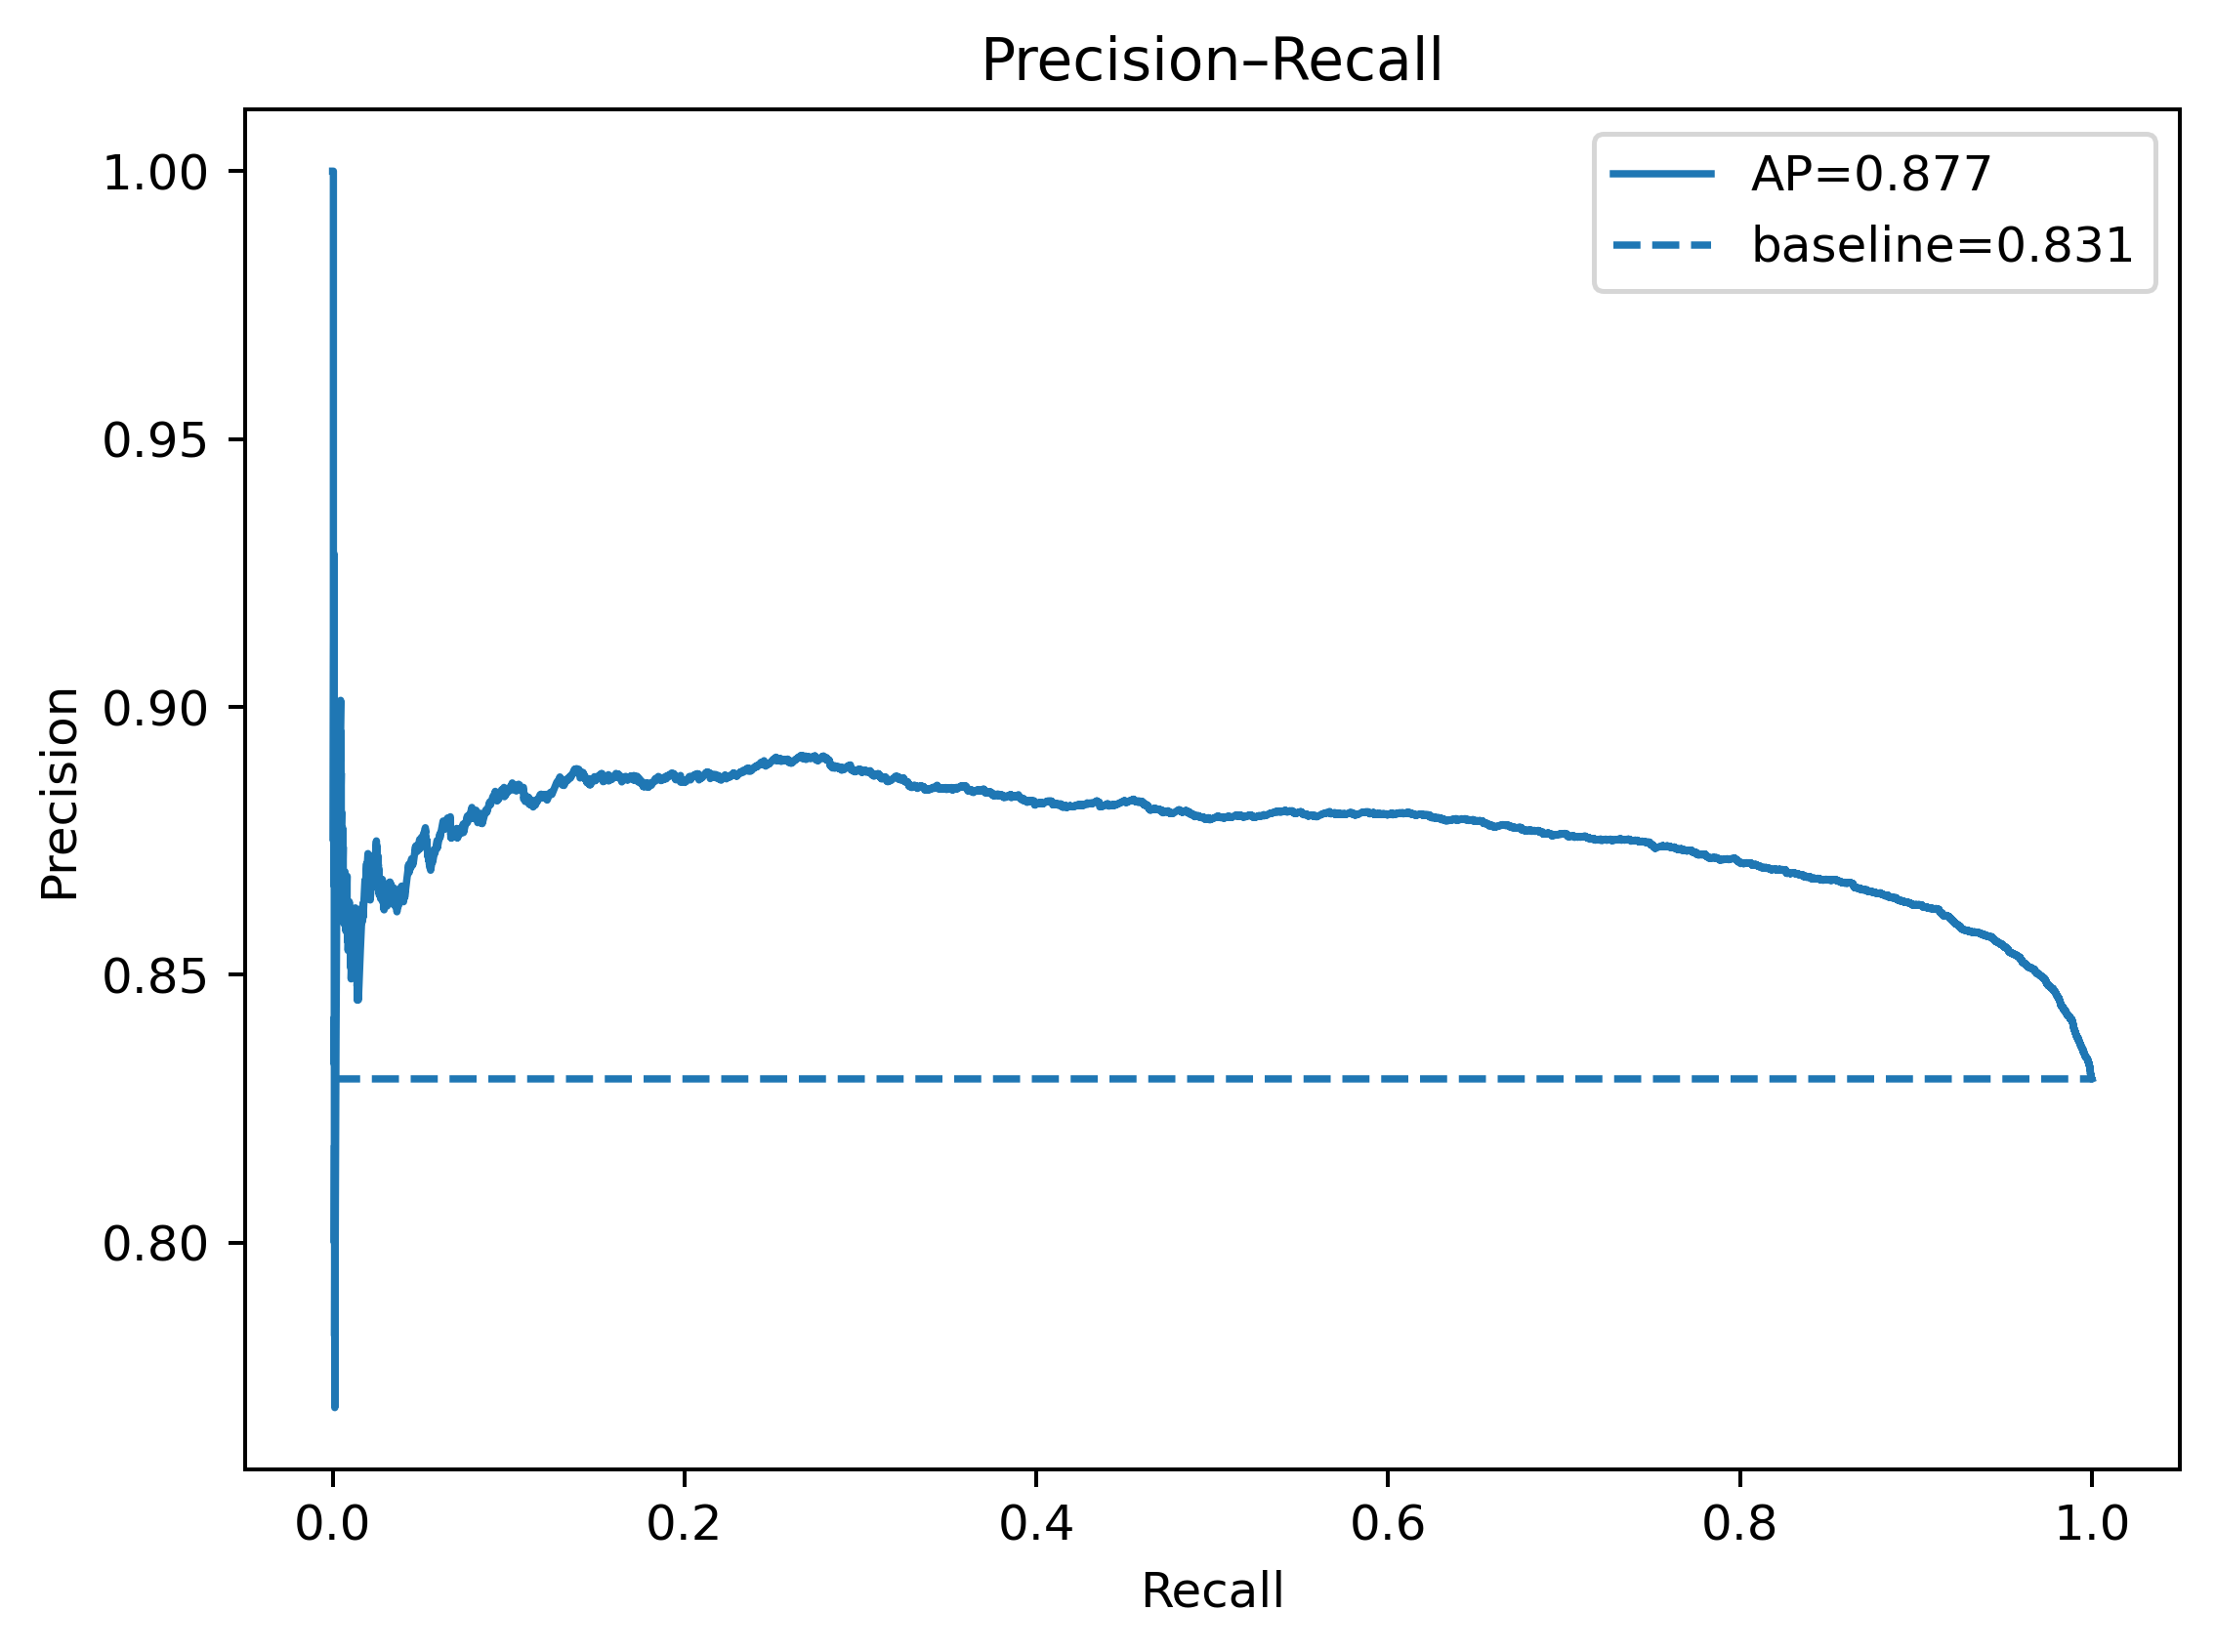

In [15]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

p, r, _ = precision_recall_curve(yte, scores)
ap = average_precision_score(yte, scores)
base = float(np.mean(yte))

plt.figure()
plt.plot(r, p, label=f"AP={ap:.3f}")
plt.hlines(base, 0, 1, linestyles="dashed", label=f"baseline={base:.3f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision–Recall")
plt.legend(); plt.show()

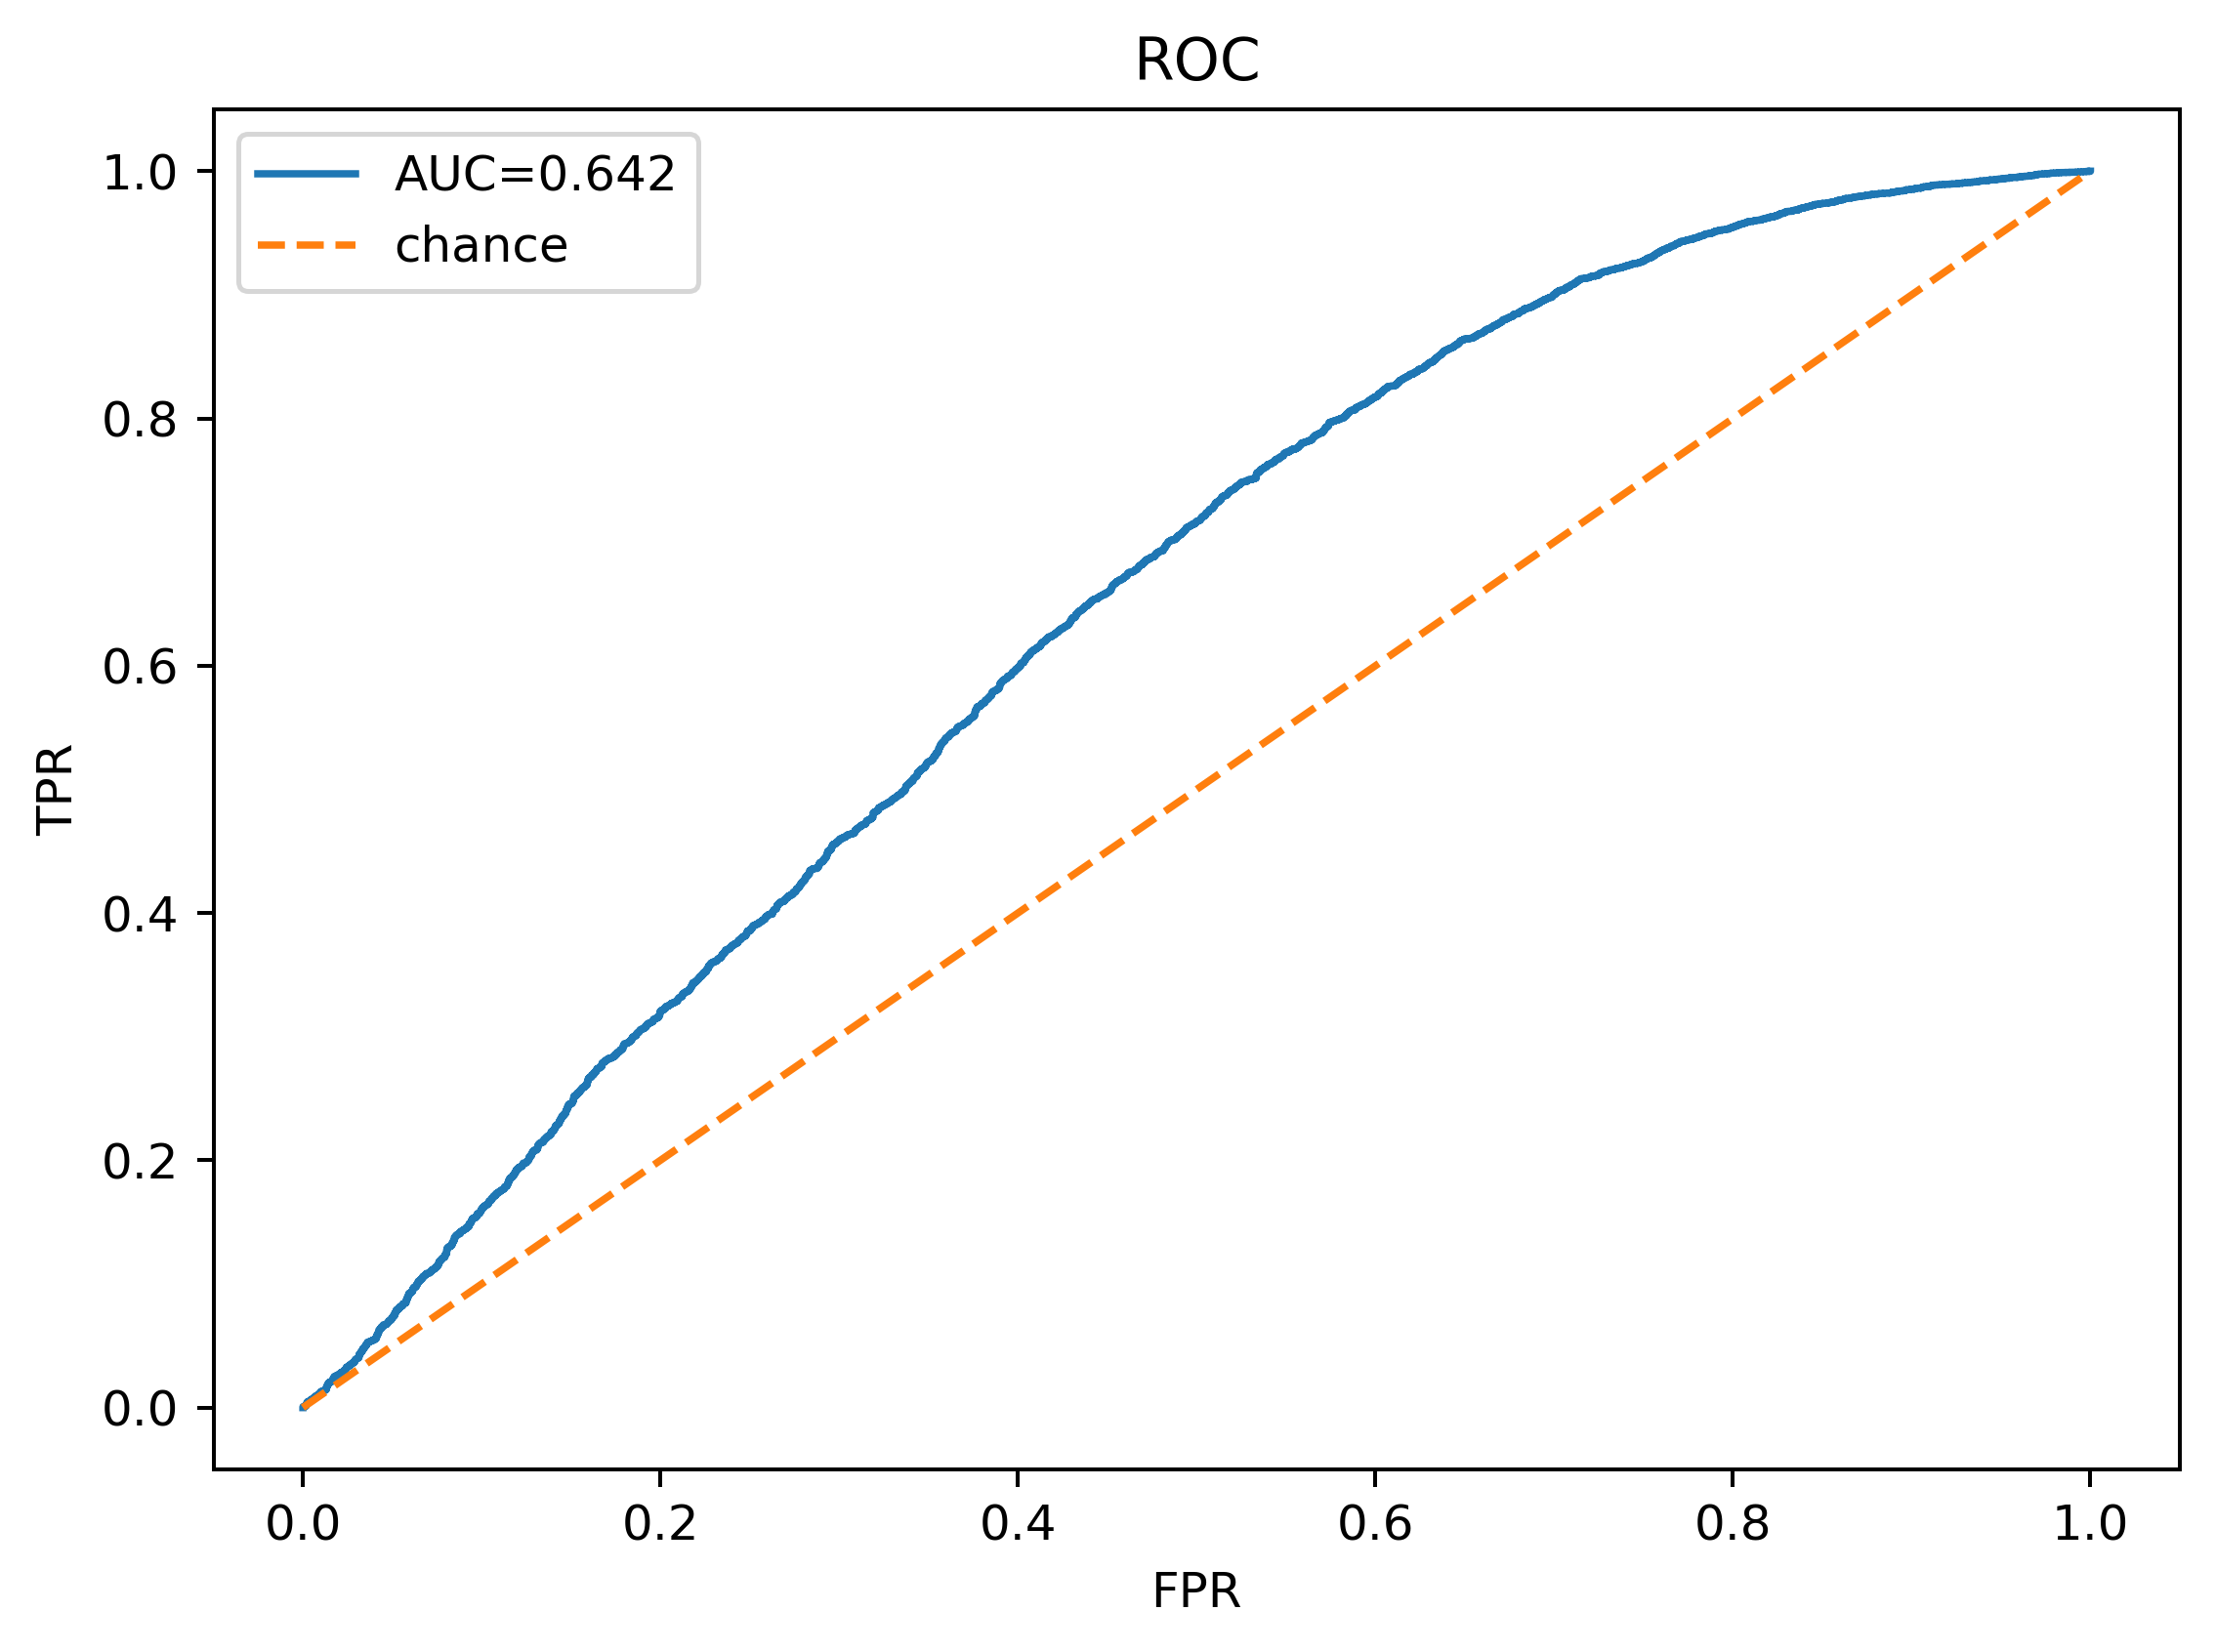

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(yte, scores)
roc = roc_auc_score(yte, scores)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={roc:.3f}")
plt.plot([0,1],[0,1], linestyle="dashed", label="chance")
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC")
plt.legend(); plt.show()

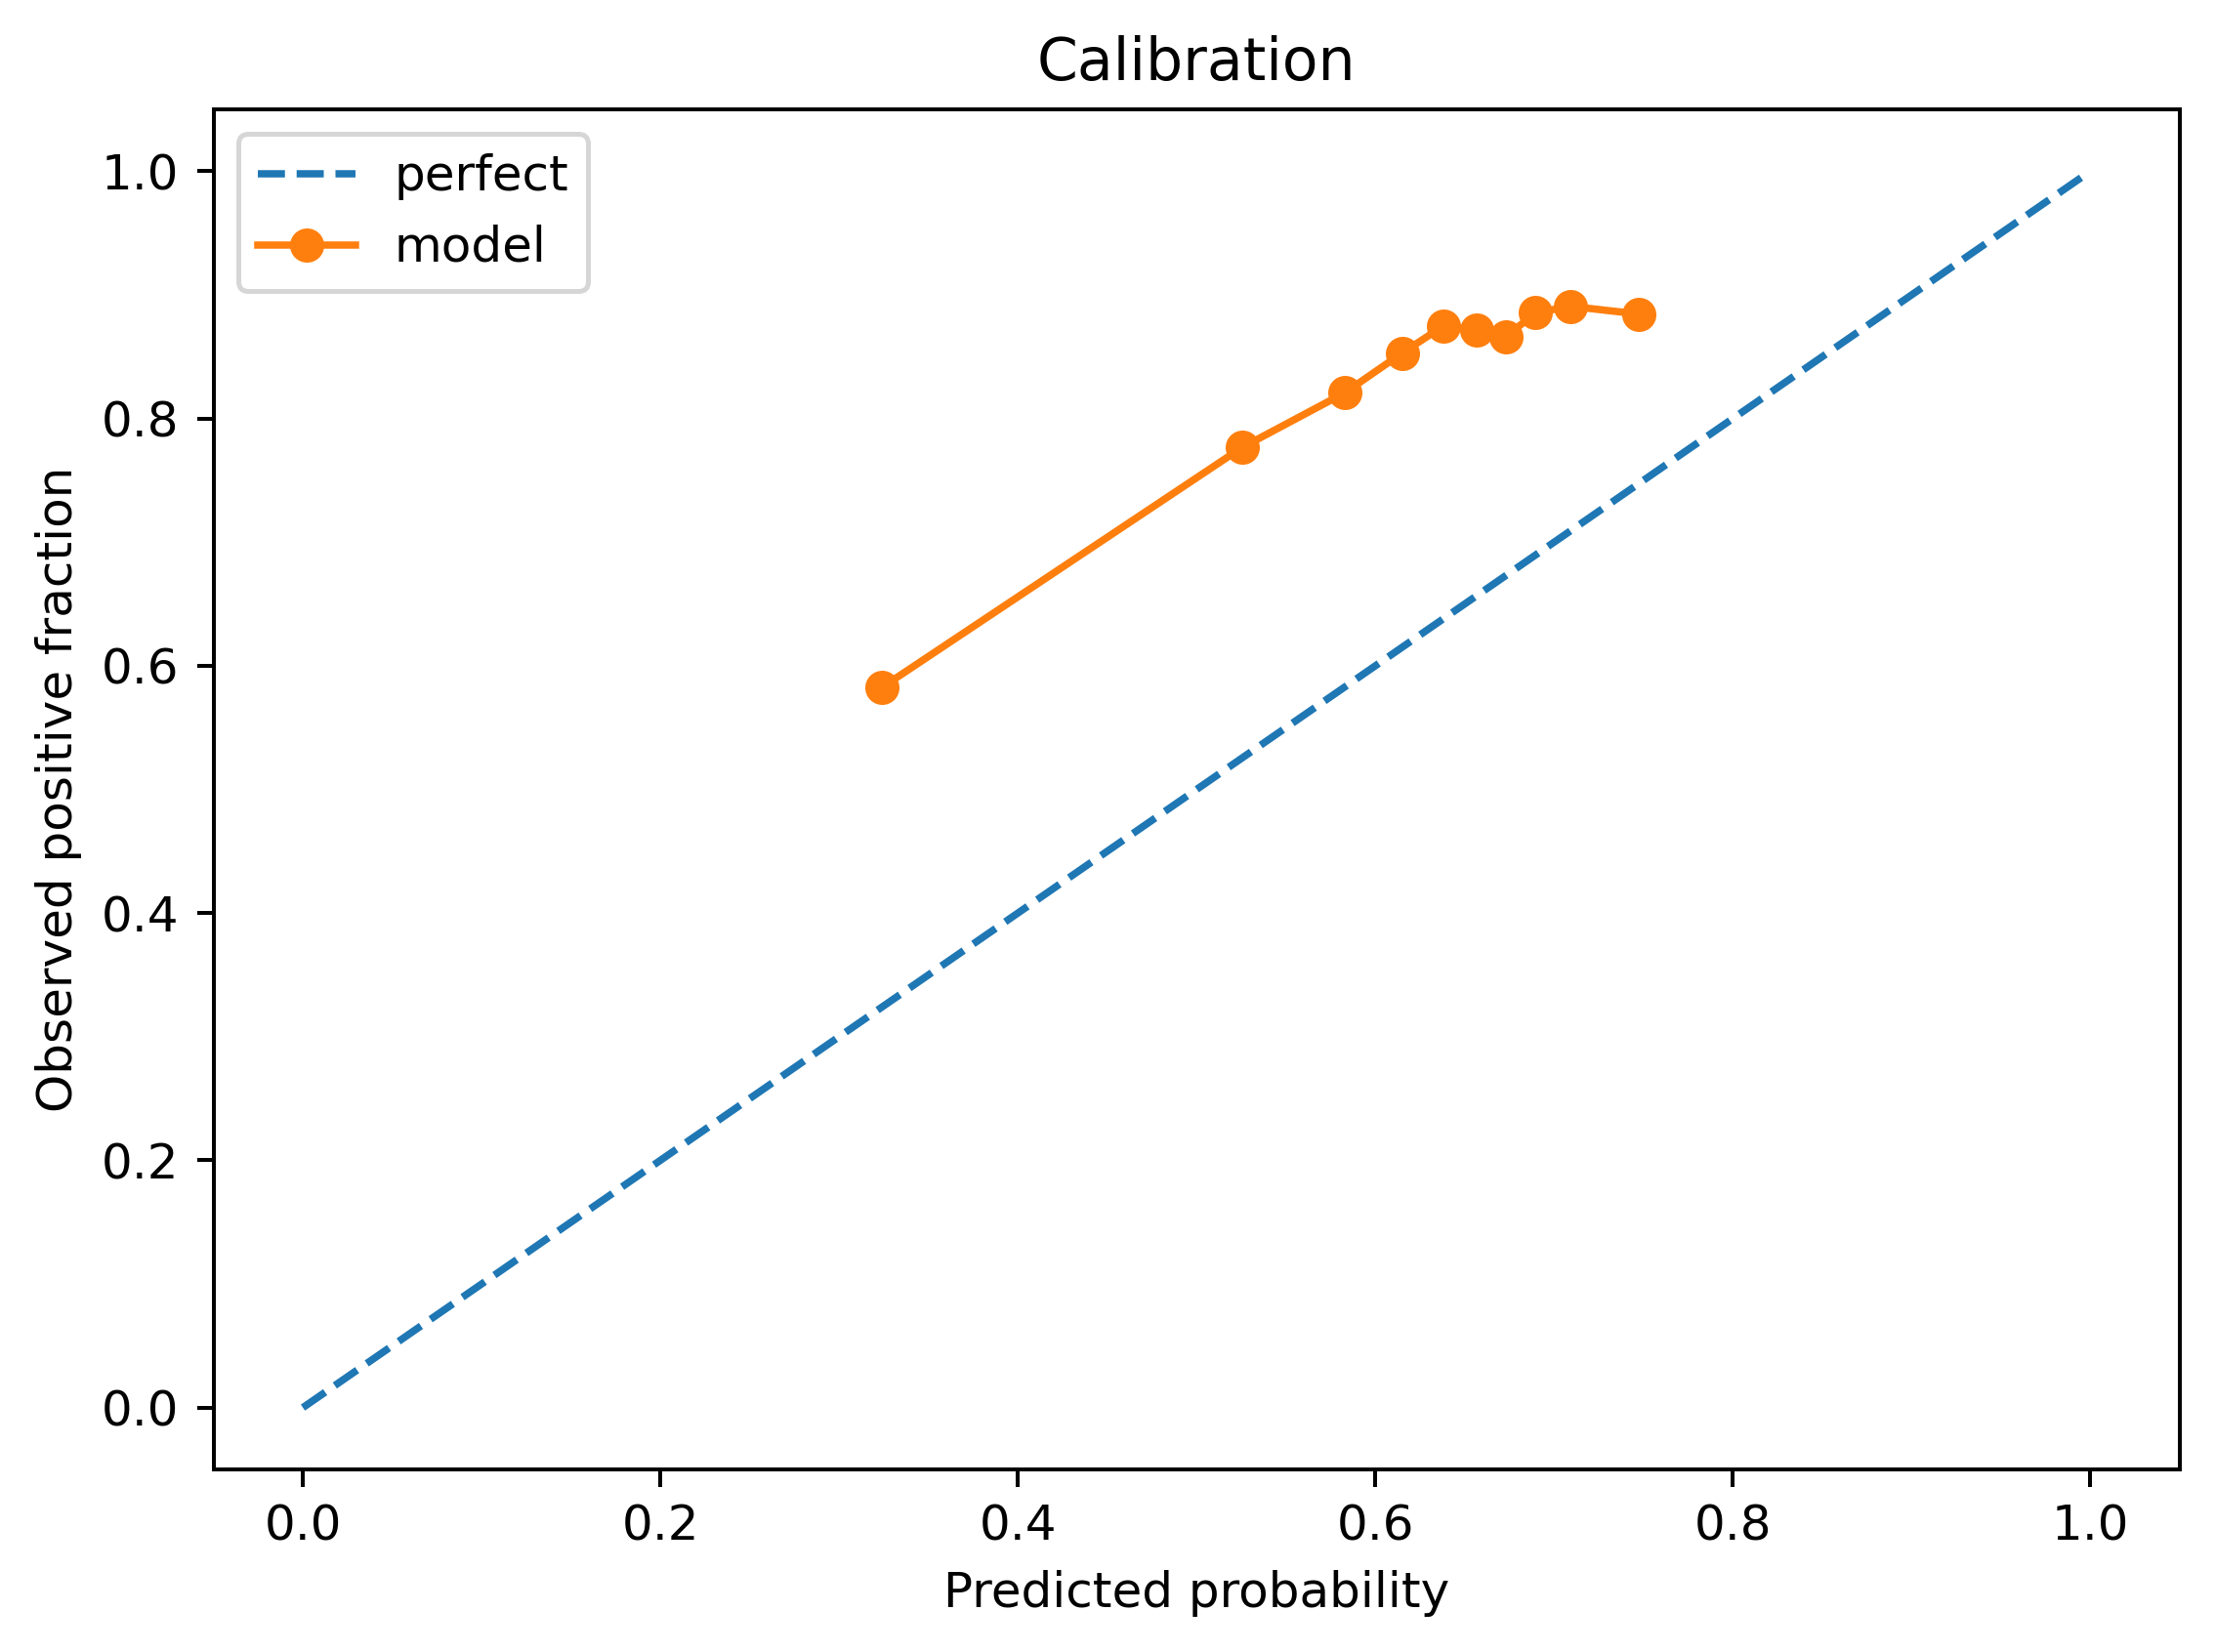

In [18]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(yte, scores, n_bins=10, strategy="quantile")

plt.figure()
plt.plot([0,1],[0,1], linestyle="dashed", label="perfect")
plt.plot(prob_pred, prob_true, marker="o", label="model")
plt.xlabel("Predicted probability"); plt.ylabel("Observed positive fraction")
plt.title("Calibration"); plt.legend(); plt.show()

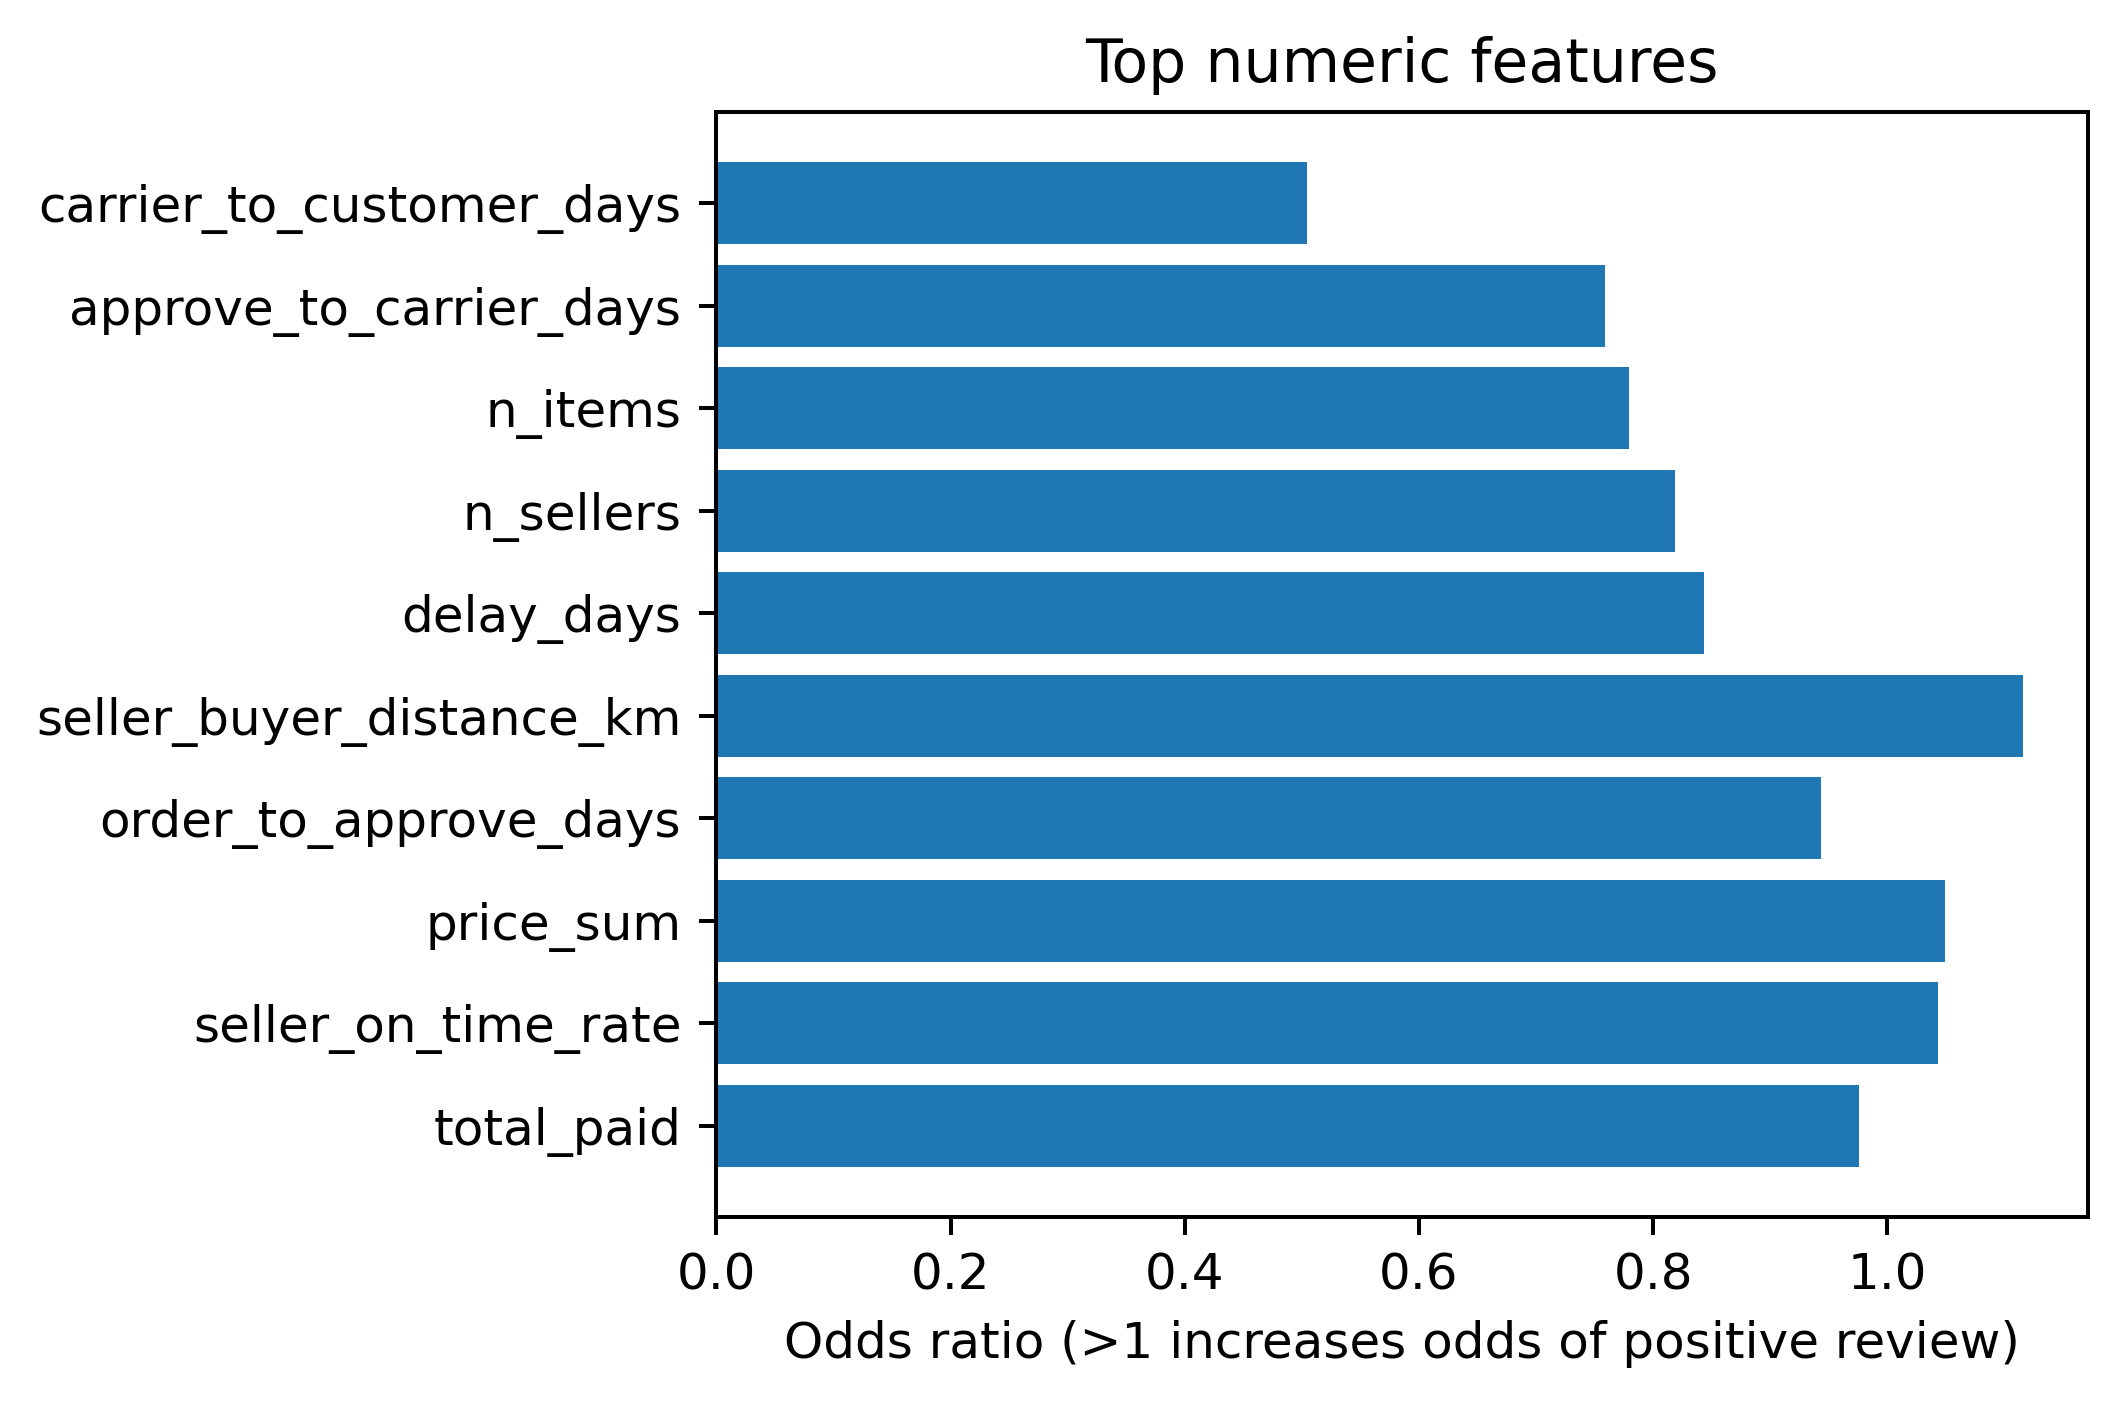

In [20]:
import numpy as np

# assumes your pipeline objects: `pre` (ColumnTransformer), `logreg` (Pipeline), and `num_cols`, `cat_cols`
coef = logreg.named_steps["clf"].coef_.ravel()
# In the earlier setup, numeric block is first in ColumnTransformer:
odds = np.exp(coef[:len(num_cols)])

order_idx = np.argsort(np.abs(np.log(odds)))[::-1][:10]  # strongest by |log-odds|
plt.figure(figsize=(6, 0.4*len(order_idx)))
plt.barh(range(len(order_idx)), odds[order_idx])
plt.yticks(range(len(order_idx)), [num_cols[i] for i in order_idx])
plt.xlabel("Odds ratio (>1 increases odds of positive review)")
plt.title("Top numeric features"); plt.gca().invert_yaxis()
plt.show()